In [11]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.collections import PatchCollection
from matplotlib.patches import Rectangle

In [12]:
workdir = Path("data/exactbo/rbf_k_bounds_workflow")

In [32]:
train_index = 2
grid_size = 160

In [33]:
X0 = np.load(workdir / "X0.npy")
y0 = np.load(workdir / "y0.npy")
bounds_L = np.load(workdir / "box_bounds_L.npy")
bounds_U = np.load(workdir / "box_bounds_U.npy")
domain_bounds = np.load(workdir / "domain_bounds.npy")
K_lo = np.load(workdir / "K_lo.npy")
K_hi = np.load(workdir / "K_hi.npy")
gp = np.load(workdir / "gpr_parameters.npz")

In [34]:
def gpr_mean_on_grid(gp, domain_bounds, grid_size):
    x_min, x_max = domain_bounds[0]
    y_min, y_max = domain_bounds[1]

    x = np.linspace(x_min, x_max, grid_size)
    y = np.linspace(y_min, y_max, grid_size)
    xx, yy = np.meshgrid(x, y)
    points = np.column_stack([xx.ravel(), yy.ravel()])

    X_train = gp["X_train"]
    alpha = gp["alpha"]
    length_scale = gp["length_scale"]
    sigma_f_squared = float(gp["sigma_f_squared"])
    y_train_mean = float(np.ravel(gp["y_train_mean"])[0])
    y_train_std = float(np.ravel(gp["y_train_std"])[0])

    scaled = (points[:, None, :] - X_train[None, :, :]) / length_scale
    sqdist = np.sum(scaled * scaled, axis=2)
    K_trans = sigma_f_squared * np.exp(-0.5 * sqdist)

    mean_scaled = K_trans @ alpha
    mean = y_train_mean + y_train_std * mean_scaled
    return xx, yy, mean.reshape(grid_size, grid_size)

In [35]:
def box_collection(bounds_L, bounds_U, values, cmap="viridis"):
    patches = []
    for lo, hi in zip(bounds_L, bounds_U):
        patches.append(
            Rectangle(
                (lo[0], lo[1]),
                hi[0] - lo[0],
                hi[1] - lo[1],
            )
        )

    collection = PatchCollection(
        patches,
        cmap=cmap,
        edgecolor="black",
        linewidth=0.9,
    )
    collection.set_array(np.asarray(values, dtype=float))
    return collection

In [36]:
xx, yy, gpr_mean = gpr_mean_on_grid(gp, domain_bounds, grid_size)

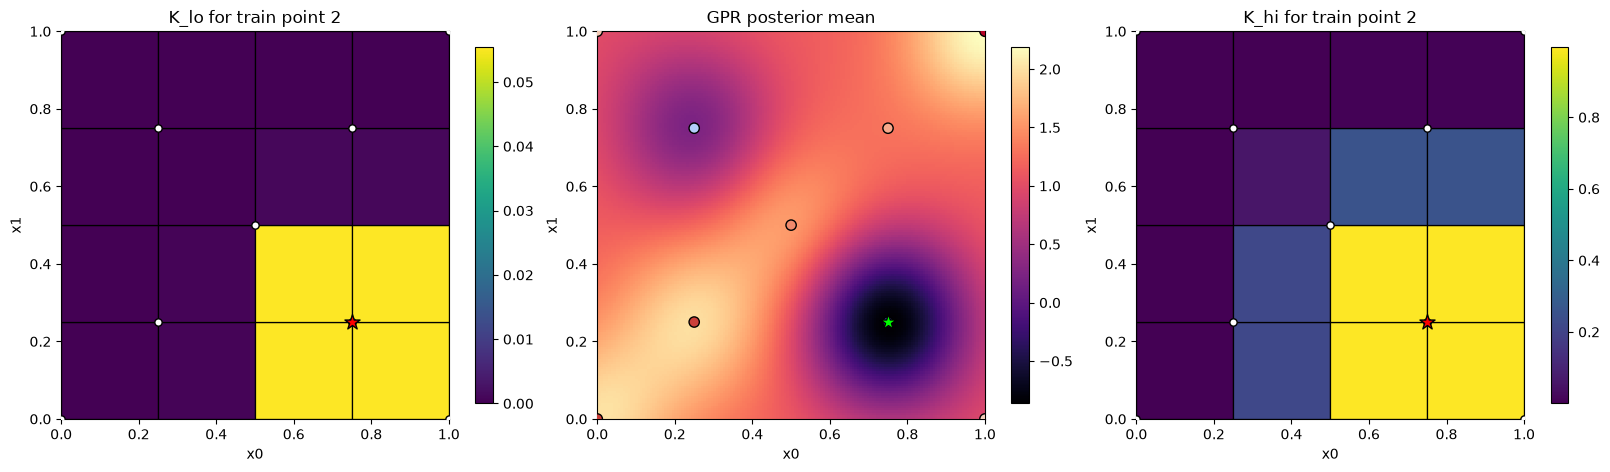

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), constrained_layout=True)
# Left: K_lo boxes
lo_coll = box_collection(bounds_L, bounds_U, K_lo[:, train_index])
axes[0].add_collection(lo_coll)
axes[0].scatter(X0[:, 0], X0[:, 1], s=28, c="white", edgecolor="black", zorder=3)
axes[0].scatter(
    X0[train_index, 0],
    X0[train_index, 1],
    s=130,
    marker="*",
    c="red",
    edgecolor="black",
    zorder=4,
)
axes[0].set_title(f"K_lo for train point {train_index}")
axes[0].set_xlabel("x0")
axes[0].set_ylabel("x1")
axes[0].set_aspect("equal", adjustable="box")
axes[0].set_xlim(domain_bounds[0, 0], domain_bounds[0, 1])
axes[0].set_ylim(domain_bounds[1, 0], domain_bounds[1, 1])
fig.colorbar(lo_coll, ax=axes[0], fraction=0.046, pad=0.04)

# Center: GPR posterior mean
mean_plot = axes[1].pcolormesh(xx, yy, gpr_mean, shading="auto", cmap="magma")
points = axes[1].scatter(
    X0[:, 0],
    X0[:, 1],
    c=y0,
    cmap="coolwarm",
    edgecolor="black",
    s=55,
    zorder=3,
)
axes[1].scatter(
    X0[train_index, 0],
    X0[train_index, 1],
    s=140,
    marker="*",
    c="lime",
    edgecolor="black",
    zorder=4,
)
axes[1].set_title("GPR posterior mean")
axes[1].set_xlabel("x0")
axes[1].set_ylabel("x1")
axes[1].set_aspect("equal", adjustable="box")
axes[1].set_xlim(domain_bounds[0, 0], domain_bounds[0, 1])
axes[1].set_ylim(domain_bounds[1, 0], domain_bounds[1, 1])
fig.colorbar(mean_plot, ax=axes[1], fraction=0.046, pad=0.04)

# Right: K_hi boxes
hi_coll = box_collection(bounds_L, bounds_U, K_hi[:, train_index])
axes[2].add_collection(hi_coll)
axes[2].scatter(X0[:, 0], X0[:, 1], s=28, c="white", edgecolor="black", zorder=3)
axes[2].scatter(
    X0[train_index, 0],
    X0[train_index, 1],
    s=130,
    marker="*",
    c="red",
    edgecolor="black",
    zorder=4,
)
axes[2].set_title(f"K_hi for train point {train_index}")
axes[2].set_xlabel("x0")
axes[2].set_ylabel("x1")
axes[2].set_aspect("equal", adjustable="box")
axes[2].set_xlim(domain_bounds[0, 0], domain_bounds[0, 1])
axes[2].set_ylim(domain_bounds[1, 0], domain_bounds[1, 1])
fig.colorbar(hi_coll, ax=axes[2], fraction=0.046, pad=0.04)

plt.show()